In [1]:
import numpy as np
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib import ticker
from scipy.optimize import curve_fit
from pylab import *
from scipy import ndimage
from matplotlib.colors import LinearSegmentedColormap
from functools import reduce
import operator

# LaTeX font
plt.rcParams.update({
    "text.usetex": True,
    'font.size': 22
    })


In [2]:
# Read in all the pressure density stuff
def convert_density(g_per_cm3):
    # Constants
    c_squared = 9e16  # Speed of light squared in m^2/s^2
    joule_to_mev = 6.242e12  # 1 Joule = 6.242e12 MeV
    m3_to_fm3 = 1e45  # 1 m^3 = 10^45 fm^3
    
    # Convert g/cm^3 to kg/m^3
    kg_per_m3 = g_per_cm3 * 1e3
    
    # Energy density in J/m^3
    energy_density_joule_per_m3 = kg_per_m3 * c_squared
    
    # Convert J/m^3 to MeV/m^3
    energy_density_mev_per_m3 = energy_density_joule_per_m3 * joule_to_mev
    
    # Convert MeV/m^3 to MeV/fm^3
    energy_density_mev_per_fm3 = energy_density_mev_per_m3 / m3_to_fm3
    
    return energy_density_mev_per_fm3

In [3]:
def convert_pressure(dyne_per_cm2):
    # Constants
    dyne_per_cm2_to_pascal = 0.1  # 1 dyne/cm^2 = 0.1 Pa
    joule_to_mev = 6.242e12  # 1 Joule = 6.242e12 MeV
    m3_to_fm3 = 1e45  # 1 m^3 = 10^45 fm^3
    
    # Convert dyne/cm^2 to Pascals (N/m^2)
    pressure_pa = dyne_per_cm2 * dyne_per_cm2_to_pascal
    
    # Convert Pa to J/m^3 (since pressure and energy density have same units)
    energy_density_joule_per_m3 = pressure_pa
    
    # Convert J/m^3 to MeV/m^3
    energy_density_mev_per_m3 = energy_density_joule_per_m3 * joule_to_mev
    
    # Convert MeV/m^3 to MeV/fm^3
    energy_density_mev_per_fm3 = energy_density_mev_per_m3 / m3_to_fm3
    
    return energy_density_mev_per_fm3

In [4]:
# Load in pressure density curves 
press_dens_GW170817_physics = np.load('eos_confidence_intervals_GW170817_physics.npz')
rho_GW170817_physics  = press_dens_GW170817_physics['rho']
rho_GW170817_physics = rho_GW170817_physics*1e-3 # Convert to cgs
press_low_GW170817_physics = 10**(press_dens_GW170817_physics['bns_logp_CIlow']+1.)
press_high_GW170817_physics = 10**(press_dens_GW170817_physics['bns_logp_CIup']+1.)

# Convert to MeV/fm^3
eng_dens_GW170817_physics = rho_GW170817_physics/1.7827e12 
# Convert to MeV/fm^3
press_low_GW170817_physics= press_low_GW170817_physics/1.6022e33
press_high_GW170817_physics = press_high_GW170817_physics/1.6022e33

In [5]:
# Load in the prior 
# Load in pressure density curves 
press_dens_physics_prior = np.load('eos_confidence_intervals_BNS_prior.npz')
rho_physics_prior  = press_dens_physics_prior['rho']
rho_physics_prior = rho_physics_prior*1e-3 # Convert to cgs
press_low_physics_prior = 10**(press_dens_physics_prior['bns_logp_CIlow']+1.)
press_high_physics_prior = 10**(press_dens_physics_prior['bns_logp_CIup']+1.)

# Convert to MeV/fm^3
eng_dens_physics_prior = rho_physics_prior/1.7827e12 
# Convert to MeV/fm^3
press_low_physics_prior= press_low_physics_prior/1.6022e33
press_high_physics_prior = press_high_physics_prior/1.6022e33

In [6]:
# Load in the prior 
# Load in pressure density curves 
press_dens_uniform_prior = np.load('eos_confidence_intervals_uniform_prior.npz')
rho_uniform_prior  = press_dens_uniform_prior['rho']
rho_uniform_prior = rho_uniform_prior*1e-3 # Convert to cgs
press_low_uniform_prior = 10**(press_dens_uniform_prior['bns_logp_CIlow']+1.)
press_high_uniform_prior = 10**(press_dens_uniform_prior['bns_logp_CIup']+1.)

# Convert to MeV/fm^3
eng_dens_uniform_prior = rho_uniform_prior/1.7827e12 
# Convert to MeV/fm^3
press_low_uniform_prior= press_low_uniform_prior/1.6022e33
press_high_uniform_prior = press_high_uniform_prior/1.6022e33

In [7]:
# Load in the prior 
# Load in pressure density curves 
press_dens_uniform = np.load('eos_confidence_intervals_uniform.npz')
rho_uniform  = press_dens_uniform['rho']
rho_uniform = rho_uniform*1e-3 # Convert to cgs
press_low_uniform = 10**(press_dens_uniform['bns_logp_CIlow']+1.)
press_high_uniform = 10**(press_dens_uniform['bns_logp_CIup']+1.)

# Convert to MeV/fm^3
eng_dens_uniform = rho_uniform/1.7827e12 
# Convert to MeV/fm^3
press_low_uniform= press_low_uniform/1.6022e33
press_high_uniform = press_high_uniform/1.6022e33
#press_eng = convert_pressure(press_low)
#print(press_eng)
#print(eng_dens)

In [8]:
import pandas as pd
mass_radius_GW170817_physics = np.load('mass_radius_curves_GW170817_physics.npz',allow_pickle=True)
#print(mass_radius.files)
masses_GW170817_physics = mass_radius_GW170817_physics['masses']
radii_Gw170817_physics = mass_radius_GW170817_physics['radii']
masses_Gw170817_physics = mass_radius_GW170817_physics['masses'].flatten()
radii_GW170817_physics = mass_radius_GW170817_physics['radii'].flatten()

# Convert to lists by concatenating sub-arrays
masses_GW170817_physics = np.concatenate(mass_radius_GW170817_physics['masses']).tolist()
radii_GW170817_physics = np.concatenate(mass_radius_GW170817_physics['radii']).tolist()

#print(radii)
#print(masses)
#print(mass_high)
#print(mass_low)
# Convert to DataFrame
df_GW170817_physics = pd.DataFrame({'Masses': masses_GW170817_physics, 'Radii': radii_GW170817_physics})

In [9]:
import pandas as pd
mass_radius_GW170817_uniform = np.load('mass_radius_curves_GW170817_uniform.npz',allow_pickle=True)
#print(mass_radius.files)
masses_GW170817_uniform = mass_radius_GW170817_uniform['masses']
radii_Gw170817_uniform = mass_radius_GW170817_uniform['radii']
masses_Gw170817_uniform = mass_radius_GW170817_uniform['masses'].flatten()
radii_GW170817_uniform = mass_radius_GW170817_uniform['radii'].flatten()

# Convert to lists by concatenating sub-arrays
masses_GW170817_uniform = np.concatenate(mass_radius_GW170817_uniform['masses']).tolist()
radii_GW170817_uniform = np.concatenate(mass_radius_GW170817_uniform['radii']).tolist()

#print(radii)
#print(masses)
#print(mass_high)
#print(mass_low)
# Convert to DataFrame
df_GW170817_uniform = pd.DataFrame({'Masses': masses_GW170817_uniform, 'Radii': radii_GW170817_uniform})

In [10]:
import pandas as pd
mass_radius_BNS_prior = np.load('mass_radius_curves_BNS_prior.npz',allow_pickle=True)
#print(mass_radius.files)
masses_BNS_prior = mass_radius_BNS_prior['masses']
radii_BNS_prior = mass_radius_BNS_prior['radii']
masses_BNS_prior = mass_radius_BNS_prior['masses'].flatten()
radii_BNS_prior = mass_radius_BNS_prior['radii'].flatten()

# Convert to lists by concatenating sub-arrays
masses_BNS_prior = np.concatenate(mass_radius_BNS_prior['masses']).tolist()
radii_BNS_prior = np.concatenate(mass_radius_BNS_prior['radii']).tolist()

#print(radii)
#print(masses)
#print(mass_high)
#print(mass_low)
# Convert to DataFrame
df_BNS_prior = pd.DataFrame({'Masses': masses_BNS_prior, 'Radii': radii_BNS_prior})

In [11]:
mass_radius_uniform_prior = np.load('mass_radius_curves_uniform_prior.npz',allow_pickle=True)
#print(mass_radius.files)
masses_uniform_prior = mass_radius_uniform_prior['masses']
radii_uniform_prior = mass_radius_uniform_prior['radii']
masses_uniform_prior = mass_radius_uniform_prior['masses'].flatten()
radii_uniform_prior = mass_radius_uniform_prior['radii'].flatten()

# Convert to lists by concatenating sub-arrays
masses_uniform_prior = np.concatenate(mass_radius_uniform_prior['masses']).tolist()
radii_uniform_prior = np.concatenate(mass_radius_uniform_prior['radii']).tolist()

#print(radii)
#print(masses)
#print(mass_high)
#print(mass_low)
# Convert to DataFrame
df_uniform_prior = pd.DataFrame({'Masses': masses_uniform_prior, 'Radii': radii_uniform_prior})

In [12]:
def mass_radius_confidence_intervals(
        result_dataframe, quantiles=[0.05,0.5,0.95],
        mass_array=np.linspace(0.5,3,100)): 
    '''
    Parameters
    ----------
    result_dataframe: pandas dataframe
        a dataframe containing radius and mass posteriors
    quantiles: list
        quantiles. Should be a list of lenght=3, by default returns
        the 90% confidence interval and the median
    mass_array: numpy array
        MUST be the same value used in 
        toast.piecewise_polytrope.mass_radius_posterior
        
    Returns
    -------
    min_radius: numpy array
        min radius encompased by the confidence interval defined by quantiles
    max_radius: numpy array
        max radius encompased by the confidence interval defined by quantiles
    median_radius: numpy array
        median radius 
    mass: numpy array
    
    '''


    mass_posteriors = result_dataframe['Masses'].values
    radius_posteriors = result_dataframe['Radii'].values
    #print(np.max(mass_posteriors))
    #print(np.max(radius_posteriors))
    
    #mass_tmp = np.linspace(0.5,3,100)
    # This array should be mass_posterios 
    mass_tmp = np.unique(mass_posteriors)
    min_radius_list = list()
    max_radius_list = list()
    median_radius_list = list()
    mass_list = list()
    for mm in mass_tmp:
        try:
            args = np.argwhere(mass_posteriors == mm)
            #print(args)
            r_min,r_median,r_max = np.quantile(
                radius_posteriors[args],quantiles)
            #print(r_min)
            min_radius_list.append(r_min)
            max_radius_list.append(r_max)
            median_radius_list.append(r_median)
            mass_list.append(mm)
        except IndexError:
            pass
    #print(min_radius_list)
    min_radius = np.array(min_radius_list)
    max_radius = np.array(max_radius_list)
    median_radius = np.array(median_radius_list)
    mass = np.array(mass_list)
        
    return min_radius, max_radius, median_radius, mass


In [13]:
min_radius_GW170817_physics, max_radius_GW170817_physics, median_radius,mass_GW170817_physics = \
mass_radius_confidence_intervals(df_GW170817_physics)
min_radius_GW170817_uniform, max_radius_GW170817_uniform, median_radius,mass_GW170817_uniform  = \
mass_radius_confidence_intervals(df_GW170817_uniform)
min_radius_BNS_prior, max_radius_BNS_prior, median_radius,mass_BNS_prior  = \
mass_radius_confidence_intervals(df_BNS_prior)
min_radius_uniform_prior, max_radius_uniform_prior, median_radius,mass_uniform_prior  = \
mass_radius_confidence_intervals(df_uniform_prior)

[171.33657061262716, 3.7790377427582174]
[171.33657061262716, 2.0832375804296883]


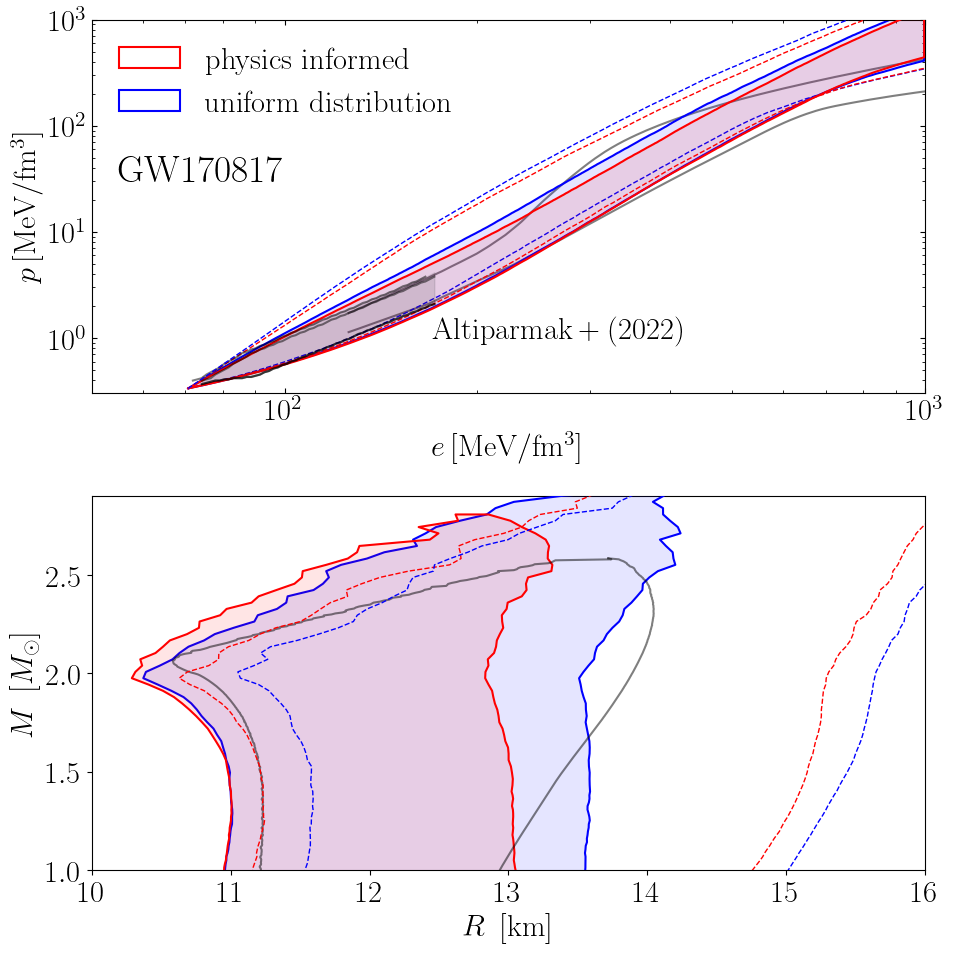

In [14]:

# CET eos
CET=np.loadtxt("CET.txt")

# pQCD band
pQCD=np.loadtxt("pQCD.txt")


# outer contours
constraint1=np.loadtxt("cloudEOS2p0.txt")
constraint2=np.loadtxt("cloudEOS2p18.txt")
constraint3=np.loadtxt("cloudEOS2p35.txt")
constraint4=np.loadtxt("cloudEOS2p52.txt")

# 90% contours
cont1=np.loadtxt("cont0p1peMtov2p0.dat")
cont2=np.loadtxt("cont0p1peMtov2p18.dat")
cont3=np.loadtxt("cont0p1peMtov2p35.dat")
cont4=np.loadtxt("cont0p1peMtov2p52.dat")


# generating a figure
fig, ax=plt.subplots(2,1,sharex=False,figsize=(10, 10),facecolor='white',dpi=100)
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlim([50,1*10**3])
ax[0].set_ylim([3e-1,10**3])
#ax.grid(color="gray", linestyle="dashed", linewidth=0.5)
ax[0].tick_params(which='major', direction='in',top="true",right="true")
ax[0].tick_params(which='minor', direction='in',top="true",right="true")
ax[0].set_xlabel(r'$e\,\rm [MeV/fm^3]$', fontsize = 22)
ax[0].set_ylabel(r'$p\,\rm [MeV/fm^3]$',fontsize = 22)

ax[0].plot(10**cont1[:,0],10**cont1[:,1], color = "black"  , linestyle = "solid",zorder=1,alpha=0.5)
ax[0].plot(10**cont1[:,0],10**cont1[:,2], color = "black"  , linestyle = "solid",zorder=1,alpha=0.5)

ax[0].plot(10**CET[:,0],10**CET[:,1], color = "black", linestyle = "solid",zorder=5,alpha=0.5,linewidth=1.5)
ax[0].plot(10**CET[:,2],10**CET[:,3], color = "black", linestyle = "solid",zorder=5,alpha=0.5,linewidth=1.5)
ax[0].fill_between(10**CET[:,0],10**CET[:,1],1.1*10**CET[:,3], color = "black" ,zorder=5,alpha=0.1)
ax[0].plot(10**CET[:,0],10**CET[:,1], color = "black" ,zorder=5,linewidth=1.5,alpha=0.5)
ax[0].plot(10**CET[:,0],10**CET[:,3], color = "black" ,zorder=5,linewidth=1.5,alpha=0.5)
print([10**CET[-1,0],10**CET[-1,3]])
print([10**CET[-1,0],10**CET[-1,1]])

ax[0].text(170, 1.0 ,r'$\rm Altiparmak+ (2022)$', fontsize = 22, color="black")
ax[0].text(55, 30.0 ,r'$\rm GW170817$', fontsize = 27, color="black")


#ax[0].text(200, 1.2 ,r'$\rm theory$', fontsize = 14, color="blue")
#plt.text(18000, 1600 ,r'$\rm pQCD$', fontsize = 14,color="green")

ax[0].fill_between(eng_dens_GW170817_physics, press_low_GW170817_physics, press_high_GW170817_physics,
                   color='red', edgecolor='none',alpha=0.1, zorder=3)
ax[0].fill_between(eng_dens_GW170817_physics, press_low_GW170817_physics, press_high_GW170817_physics, 
                   color='none',edgecolor='red',label=r'$\rm physics~informed$',alpha=1.0,linewidth=1.5,zorder=3)

ax[0].plot(eng_dens_uniform_prior, press_low_uniform_prior,color='blue', alpha=1.0, zorder=2,linestyle='dashed',linewidth=1.0)
ax[0].plot(eng_dens_uniform_prior, press_high_uniform_prior,color='blue', alpha=1.0, zorder=6,linestyle='dashed',linewidth=1.0)

ax[0].fill_between(eng_dens_uniform, press_low_uniform, press_high_uniform, color='blue', edgecolor='none',alpha=0.1, zorder=2)
ax[0].fill_between(eng_dens_uniform, press_low_uniform, press_high_uniform, color='none', edgecolor='blue',label=r'$\rm uniform~distribution$',linewidth=1.5, alpha=1.0, zorder=2)

ax[0].plot(eng_dens_physics_prior, press_low_physics_prior, color='red', alpha=1.0,linestyle='dashed',linewidth=1.0,zorder=3)
ax[0].plot(eng_dens_physics_prior,press_high_physics_prior, color='red', alpha=1.0,linestyle='dashed',linewidth=1.0,zorder=3)
ax[0].legend(loc="upper left",fontsize=22,frameon=False)
#plt.savefig('press_dens_GW170817_w_prior.pdf',dpi=500)

# Now do the mass-radius plot 

# MR-envlope
envel1=np.loadtxt("cloudMR2p0.txt")
envel2=np.loadtxt("cloudMR2p18.txt")
envel3=np.loadtxt("cloudMR2p35.txt")
envel4=np.loadtxt("cloudMR2p52.txt")

# 90% contours
cont1=np.loadtxt("cont0p1Mtov2p0.dat")
cont2=np.loadtxt("cont0p1Mtov2p18.dat")
cont3=np.loadtxt("cont0p1Mtov2p35.dat")
cont4=np.loadtxt("cont0p1Mtov2p52.dat")
# dirty trick to close the contour
cont4[-1,2]=cont4[-1,1]
cont3[-1,2]=cont3[-1,1]


ax[1].set_xlim([10,16])
ax[1].set_ylim([1,2.9])
ax[1].set_ylabel(r'$ M~\left[M_\odot\right]$',fontsize=22)
ax[1].set_xlabel(r'$R~\left[{\rm km}\right]$',fontsize=22)


# contours
ax[1].plot( cont1[:,1], cont1[:,0], color = "black"  , linestyle = "-",zorder=7,alpha=0.5,linewidth=1.5)
ax[1].plot( cont1[:,2], cont1[:,0], color = "black"  , linestyle = "-",zorder=7,label=r"$M_{\rm TOV}\geq 2.0\,M_\odot$",alpha=0.5,linewidth=1.5)
#ax[1].legend(loc="upper left",fontsize=16,frameon=False)
# save the plot

# GW170817 with physics 
ax[1].fill_betweenx(mass_GW170817_physics,min_radius_GW170817_physics,max_radius_GW170817_physics,color="red",edgecolor='none',zorder=5,alpha=0.1)
ax[1].fill_betweenx(mass_GW170817_physics,min_radius_GW170817_physics,max_radius_GW170817_physics,color="none",edgecolor='red',zorder=5,alpha=1.0,linewidth=1.5)

ax[1].fill_betweenx(mass_GW170817_uniform,min_radius_GW170817_uniform,max_radius_GW170817_uniform,color='blue',edgecolor="none",zorder=4,alpha=0.1)
ax[1].fill_betweenx(mass_GW170817_uniform,min_radius_GW170817_uniform,max_radius_GW170817_uniform,color='none', edgecolor="blue",zorder=4,alpha=1.0,linewidth=1.5)

ax[1].fill_betweenx(mass_BNS_prior,min_radius_BNS_prior,max_radius_BNS_prior, edgecolor = "red" ,facecolor='none',zorder=7,linestyle='dashed')
ax[1].fill_betweenx(mass_uniform_prior,min_radius_uniform_prior,max_radius_uniform_prior, edgecolor = "blue" ,facecolor='none',zorder=7,linestyle='dashed')


#ax[0].set_box_aspect(1)
#ax[1].set_box_aspect(1)
plt.tight_layout()
plt.savefig("GW170817_press_dens_MR_altiparmak.pdf")

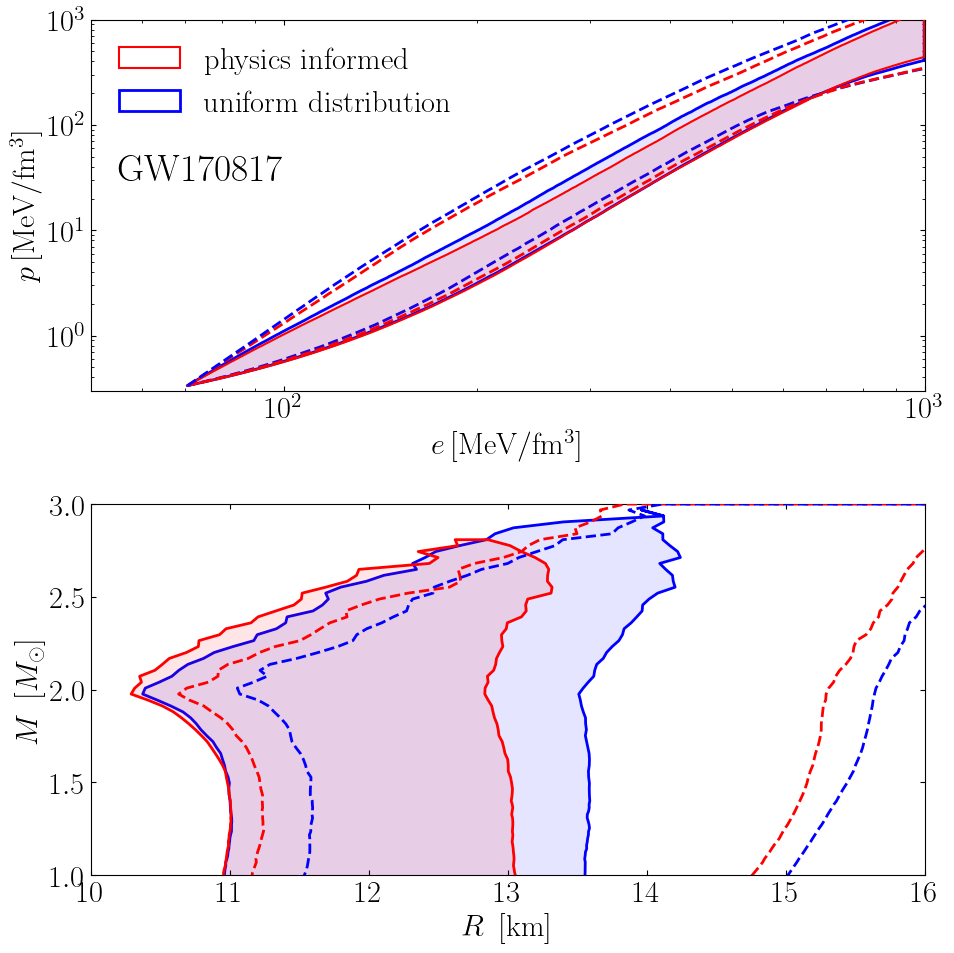

In [17]:

# CET eos
CET=np.loadtxt("CET.txt")

# pQCD band
pQCD=np.loadtxt("pQCD.txt")


# outer contours
constraint1=np.loadtxt("cloudEOS2p0.txt")
constraint2=np.loadtxt("cloudEOS2p18.txt")
constraint3=np.loadtxt("cloudEOS2p35.txt")
constraint4=np.loadtxt("cloudEOS2p52.txt")

# 90% contours
cont1=np.loadtxt("cont0p1peMtov2p0.dat")
cont2=np.loadtxt("cont0p1peMtov2p18.dat")
cont3=np.loadtxt("cont0p1peMtov2p35.dat")
cont4=np.loadtxt("cont0p1peMtov2p52.dat")


# generating a figure
fig, ax=plt.subplots(2,1,sharex=False,figsize=(10, 10),facecolor='white',dpi=100)
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlim([50,1*10**3])
ax[0].set_ylim([3e-1,10**3])
#ax.grid(color="gray", linestyle="dashed", linewidth=0.5)
ax[0].tick_params(which='major', direction='in',top="true",right="true")
ax[0].tick_params(which='minor', direction='in',top="true",right="true")
ax[0].set_xlabel(r'$e\,\rm [MeV/fm^3]$', fontsize = 22)
ax[0].set_ylabel(r'$p\,\rm [MeV/fm^3]$',fontsize = 22)

#ax[0].plot(10**cont1[:,0],10**cont1[:,1], color = "black"  , linestyle = "solid",zorder=1,alpha=0.5)
#ax[0].plot(10**cont1[:,0],10**cont1[:,2], color = "black"  , linestyle = "solid",zorder=1,alpha=0.5)

#ax[0].plot(10**CET[:,0],10**CET[:,1], color = "black", linestyle = "solid",zorder=5,alpha=0.5,linewidth=1.5)
#ax[0].plot(10**CET[:,2],10**CET[:,3], color = "black", linestyle = "solid",zorder=5,alpha=0.5,linewidth=1.5)
#ax[0].fill_between(10**CET[:,0],10**CET[:,1],1.1*10**CET[:,3], color = "black" ,zorder=5,alpha=0.1)
#ax[0].plot(10**CET[:,0],10**CET[:,1], color = "black" ,zorder=5,linewidth=1.5,alpha=0.5)
#ax[0].plot(10**CET[:,0],10**CET[:,3], color = "black" ,zorder=5,linewidth=1.5,alpha=0.5)
#print([10**CET[-1,0],10**CET[-1,3]])
#print([10**CET[-1,0],10**CET[-1,1]])

#ax[0].text(170, 1.0 ,r'$\rm Altiparmak+ (2022)$', fontsize = 22, color="black")
ax[0].text(55, 30.0 ,r'$\rm GW170817$', fontsize = 27, color="black")


#ax[0].text(200, 1.2 ,r'$\rm theory$', fontsize = 14, color="blue")
#plt.text(18000, 1600 ,r'$\rm pQCD$', fontsize = 14,color="green")

ax[0].fill_between(eng_dens_GW170817_physics, press_low_GW170817_physics, press_high_GW170817_physics,
                   color='red', edgecolor='none',alpha=0.1, zorder=3)
ax[0].fill_between(eng_dens_GW170817_physics, press_low_GW170817_physics, press_high_GW170817_physics, 
                   color='none',edgecolor='red',label=r'$\rm physics~informed$',alpha=1.0,linewidth=1.5,zorder=3)

ax[0].plot(eng_dens_uniform_prior, press_low_uniform_prior,color='blue', alpha=1.0, zorder=2,linestyle='dashed',linewidth=2.0)
ax[0].plot(eng_dens_uniform_prior, press_high_uniform_prior,color='blue', alpha=1.0, zorder=6,linestyle='dashed',linewidth=2.0)

ax[0].fill_between(eng_dens_uniform, press_low_uniform, press_high_uniform, color='blue', edgecolor='none',alpha=0.1, zorder=2)
ax[0].fill_between(eng_dens_uniform, press_low_uniform, press_high_uniform, color='none', edgecolor='blue',label=r'$\rm uniform~distribution$',linewidth=2.0, alpha=1.0, zorder=2)

ax[0].plot(eng_dens_physics_prior, press_low_physics_prior, color='red', alpha=1.0,linestyle='dashed',linewidth=2.0,zorder=3)
ax[0].plot(eng_dens_physics_prior,press_high_physics_prior, color='red', alpha=1.0,linestyle='dashed',linewidth=2.0,zorder=3)
ax[0].legend(loc="upper left",fontsize=22,frameon=False)
#plt.savefig('press_dens_GW170817_w_prior.pdf',dpi=500)

# Now do the mass-radius plot 

# MR-envlope
envel1=np.loadtxt("cloudMR2p0.txt")
envel2=np.loadtxt("cloudMR2p18.txt")
envel3=np.loadtxt("cloudMR2p35.txt")
envel4=np.loadtxt("cloudMR2p52.txt")

# 90% contours
cont1=np.loadtxt("cont0p1Mtov2p0.dat")
cont2=np.loadtxt("cont0p1Mtov2p18.dat")
cont3=np.loadtxt("cont0p1Mtov2p35.dat")
cont4=np.loadtxt("cont0p1Mtov2p52.dat")
# dirty trick to close the contour
cont4[-1,2]=cont4[-1,1]
cont3[-1,2]=cont3[-1,1]


ax[1].set_xlim([10,16])
ax[1].set_ylim([1,3.0])
ax[1].set_ylabel(r'$ M~\left[M_\odot\right]$',fontsize=22)
ax[1].set_xlabel(r'$R~\left[{\rm km}\right]$',fontsize=22)
ax[1].tick_params(which='major', direction='in',top="true",right="true")
ax[1].tick_params(which='minor', direction='in',top="true",right="true")


# contours
#ax[1].plot( cont1[:,1], cont1[:,0], color = "black"  , linestyle = "-",zorder=7,alpha=0.5,linewidth=1.5)
#ax[1].plot( cont1[:,2], cont1[:,0], color = "black"  , linestyle = "-",zorder=7,label=r"$M_{\rm TOV}\geq 2.0\,M_\odot$",alpha=0.5,linewidth=1.5)
#ax[1].legend(loc="upper left",fontsize=16,frameon=False)
# save the plot

# GW170817 with physics 
ax[1].fill_betweenx(mass_GW170817_physics,min_radius_GW170817_physics,max_radius_GW170817_physics,color="red",edgecolor='none',zorder=5,alpha=0.1)
ax[1].fill_betweenx(mass_GW170817_physics,min_radius_GW170817_physics,max_radius_GW170817_physics,color="none",edgecolor='red',zorder=5,alpha=1.0,linewidth=2.0)

ax[1].fill_betweenx(mass_GW170817_uniform,min_radius_GW170817_uniform,max_radius_GW170817_uniform,color='blue',edgecolor="none",zorder=4,alpha=0.1)
ax[1].fill_betweenx(mass_GW170817_uniform,min_radius_GW170817_uniform,max_radius_GW170817_uniform,color='none', edgecolor="blue",zorder=4,alpha=1.0,linewidth=2.0)

ax[1].fill_betweenx(mass_BNS_prior,min_radius_BNS_prior,max_radius_BNS_prior, edgecolor = "red" ,facecolor='none',zorder=7,linestyle='dashed',linewidth=2.0)
ax[1].fill_betweenx(mass_uniform_prior,min_radius_uniform_prior,max_radius_uniform_prior, edgecolor = "blue" ,facecolor='none',zorder=7,linestyle='dashed',linewidth=2.0)


#ax[0].set_box_aspect(1)
#ax[1].set_box_aspect(1)
plt.tight_layout()
plt.savefig("GW170817_press_dens_MR.pdf")